In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Convert Churn to numeric for correlation
df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


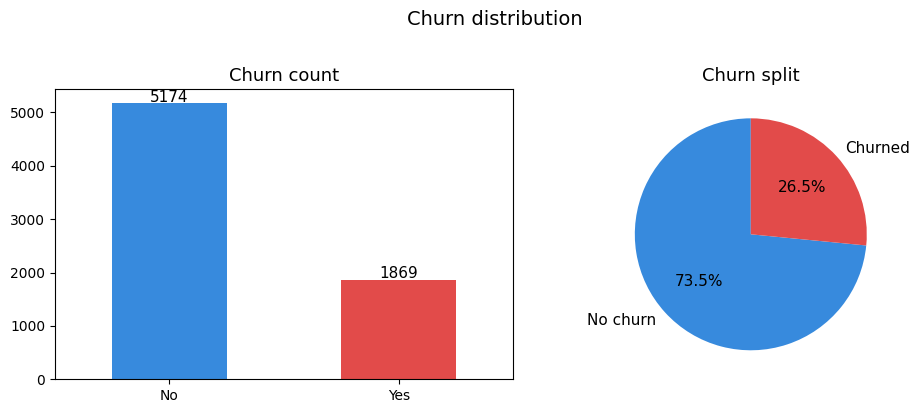

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ['#378ADD', '#E24B4A']

# Count
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='none')
axes[0].set_title('Churn count', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height())}', ha='center', fontsize=11)

# Percentage
sizes = df['Churn'].value_counts()
axes[1].pie(sizes, labels=['No churn', 'Churned'], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Churn split', fontsize=13)

plt.suptitle('Churn distribution', fontsize=14, fontweight='500', y=1.02)
plt.tight_layout()
plt.savefig('chart_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

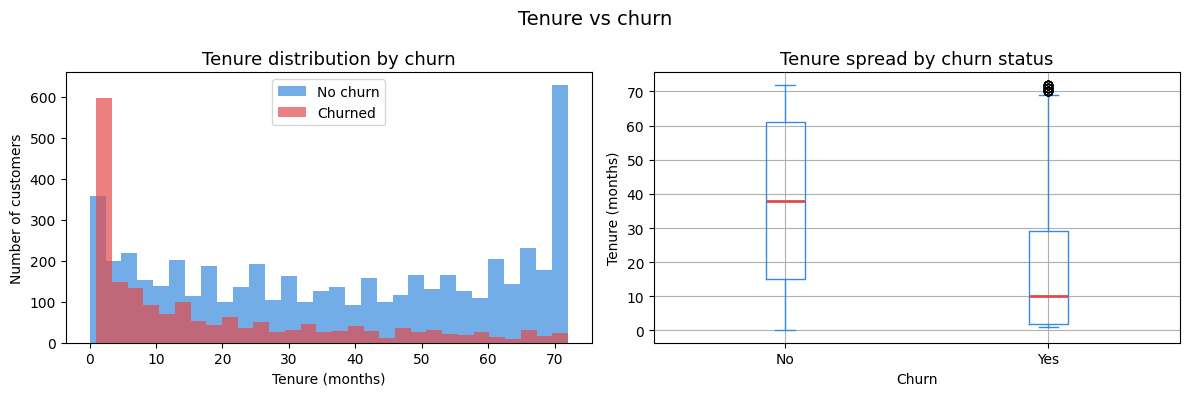

Average tenure — Churned:     18.0 months
Average tenure — Not churned: 37.6 months


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram: tenure distribution by churn status
churned     = df[df['Churn'] == 'Yes']['tenure']
not_churned = df[df['Churn'] == 'No']['tenure']

axes[0].hist(not_churned, bins=30, alpha=0.7, color='#378ADD', label='No churn')
axes[0].hist(churned,     bins=30, alpha=0.7, color='#E24B4A', label='Churned')
axes[0].set_title('Tenure distribution by churn', fontsize=13)
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of customers')
axes[0].legend()

# Boxplot: tenure spread
df.boxplot(column='tenure', by='Churn', ax=axes[1],
           boxprops=dict(color='#378ADD'),
           medianprops=dict(color='#E24B4A', linewidth=2),
           whiskerprops=dict(color='#378ADD'),
           capprops=dict(color='#378ADD'))
axes[1].set_title('Tenure spread by churn status', fontsize=13)
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tenure (months)')
plt.suptitle('')

plt.suptitle('Tenure vs churn', fontsize=14, fontweight='500')
plt.tight_layout()
plt.savefig('chart_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average tenure — Churned:     {churned.mean():.1f} months")
print(f"Average tenure — Not churned: {not_churned.mean():.1f} months")

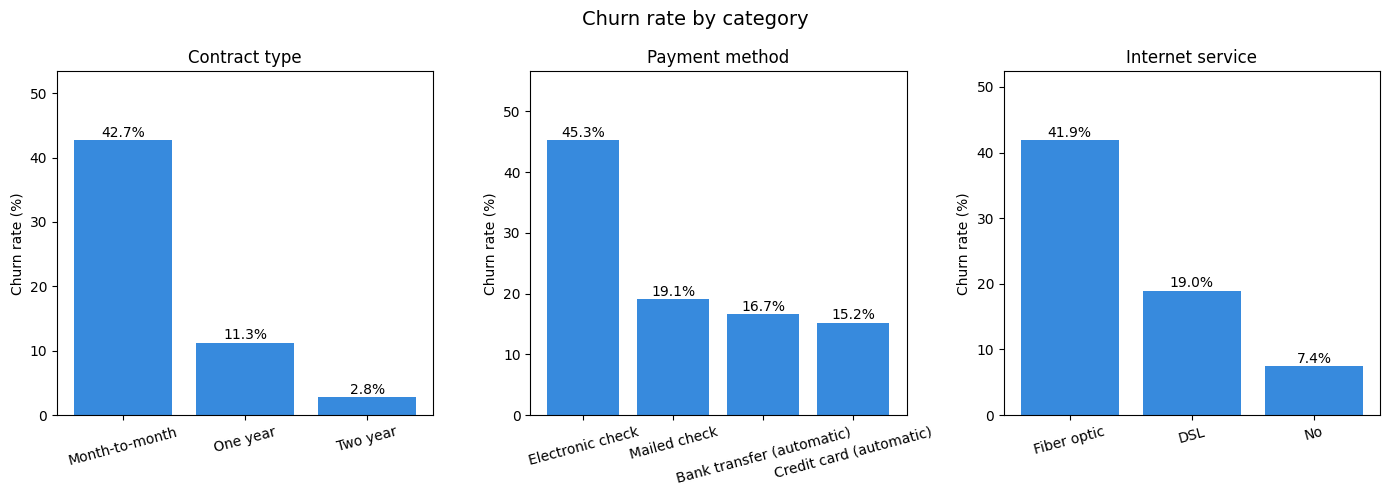

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

cat_cols = ['Contract', 'PaymentMethod', 'InternetService']
titles   = ['Contract type', 'Payment method', 'Internet service']

for ax, col, title in zip(axes, cat_cols, titles):
    churn_rate = df.groupby(col)['Churn_num'].mean().mul(100).sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values, color='#378ADD', edgecolor='none')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Churn rate (%)')
    ax.set_ylim(0, churn_rate.max() * 1.25)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=10)

plt.suptitle('Churn rate by category', fontsize=14, fontweight='500')
plt.tight_layout()
plt.savefig('chart_categories.png', dpi=150, bbox_inches='tight')
plt.show()

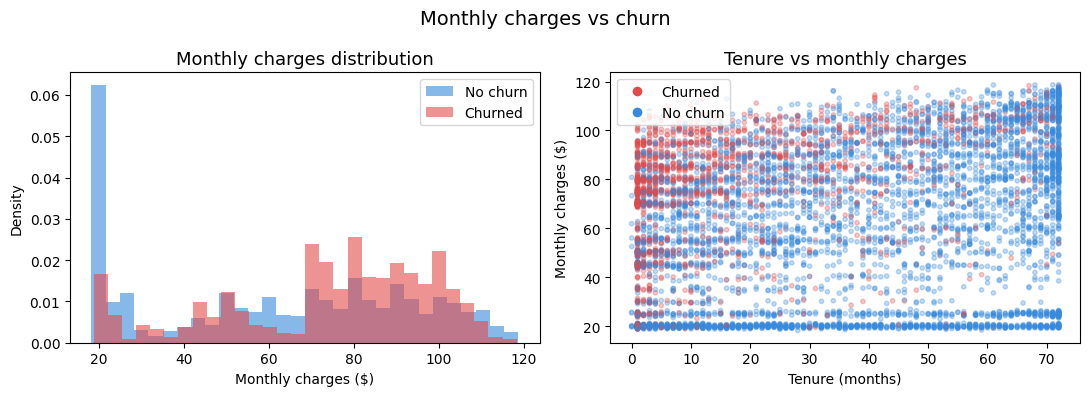

Avg monthly charges — Churned:     $74.44
Avg monthly charges — Not churned: $61.27


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# KDE plot
for label, color in [('No', '#378ADD'), ('Yes', '#E24B4A')]:
    subset = df[df['Churn'] == label]['MonthlyCharges']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color,
                 label=f'{"Churned" if label=="Yes" else "No churn"}', density=True)
axes[0].set_title('Monthly charges distribution', fontsize=13)
axes[0].set_xlabel('Monthly charges ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Scatter: tenure vs monthly charges, colored by churn
colors_map = df['Churn'].map({'No': '#378ADD', 'Yes': '#E24B4A'})
axes[1].scatter(df['tenure'], df['MonthlyCharges'],
                c=colors_map, alpha=0.3, s=10)
axes[1].set_title('Tenure vs monthly charges', fontsize=13)
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Monthly charges ($)')

from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w', markerfacecolor='#E24B4A', markersize=8, label='Churned'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='#378ADD', markersize=8, label='No churn')]
axes[1].legend(handles=legend_elements)

plt.suptitle('Monthly charges vs churn', fontsize=14, fontweight='500')
plt.tight_layout()
plt.savefig('chart_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg monthly charges — Churned:     ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"Avg monthly charges — Not churned: ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")

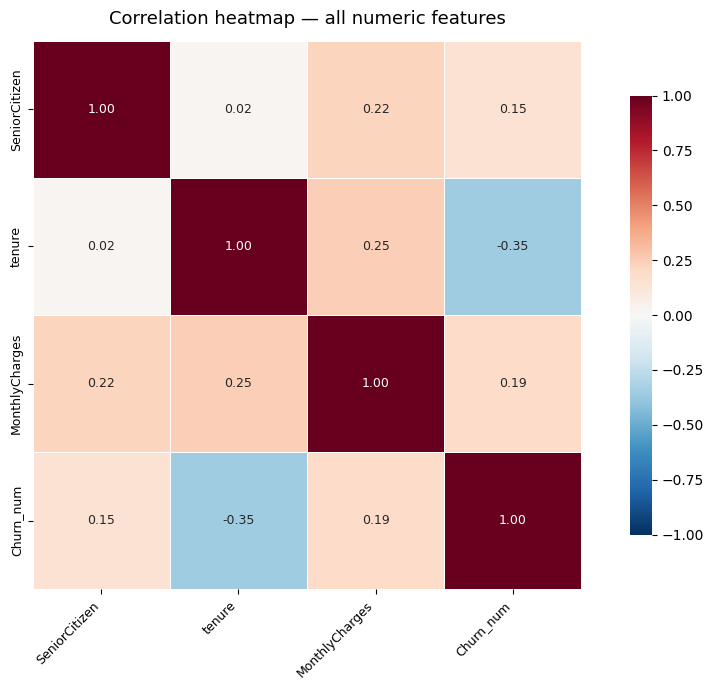


Top features correlated with churn:
tenure           -0.352
MonthlyCharges    0.193
SeniorCitizen     0.151
Name: Churn_num, dtype: float64


In [7]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix  = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})

plt.title('Correlation heatmap — all numeric features', fontsize=13, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('chart_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with Churn
print("\nTop features correlated with churn:")
print(corr_matrix['Churn_num'].drop('Churn_num').sort_values(key=abs, ascending=False).round(3))

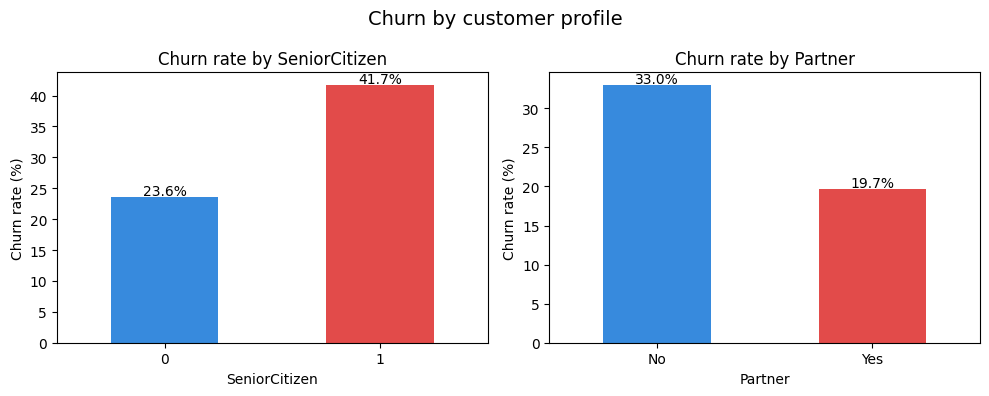

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

binary_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService']

churn_rates = {col: df.groupby(col)['Churn_num'].mean().mul(100) for col in binary_cols}

for i, (col, rates) in enumerate(list(churn_rates.items())[:2]):
    rates.plot(kind='bar', ax=axes[i], color=['#378ADD','#E24B4A'], edgecolor='none')
    axes[i].set_title(f'Churn rate by {col}', fontsize=12)
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].tick_params(rotation=0)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.suptitle('Churn by customer profile', fontsize=14, fontweight='500')
plt.tight_layout()
plt.savefig('chart_profile.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print("=" * 50)
print("EDA KEY FINDINGS SUMMARY")
print("=" * 50)

total        = len(df)
churned      = df['Churn_num'].sum()
churn_rate   = churned / total * 100

print(f"\nTotal customers:  {total:,}")
print(f"Churned:          {churned:,} ({churn_rate:.1f}%)")
print(f"Retained:         {total - churned:,} ({100 - churn_rate:.1f}%)")

print("\nAvg tenure:")
print(f"  Churned:     {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")
print(f"  Retained:    {df[df['Churn']=='No']['tenure'].mean():.1f} months")

print("\nChurn rate by contract:")
print(df.groupby('Contract')['Churn_num'].mean().mul(100).round(1).astype(str) + '%')

print("\nTop 3 churn drivers (by correlation):")
top3 = corr_matrix['Churn_num'].drop('Churn_num').sort_values(key=abs, ascending=False).head(3)
for feat, val in top3.items():
    direction = 'increases' if val > 0 else 'decreases'
    print(f"  {feat}: r={val:.3f} — higher value {direction} churn risk")

EDA KEY FINDINGS SUMMARY

Total customers:  7,043
Churned:          1,869 (26.5%)
Retained:         5,174 (73.5%)

Avg tenure:
  Churned:     18.0 months
  Retained:    37.6 months

Churn rate by contract:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn_num, dtype: object

Top 3 churn drivers (by correlation):
  tenure: r=-0.352 — higher value decreases churn risk
  MonthlyCharges: r=0.193 — higher value increases churn risk
  SeniorCitizen: r=0.151 — higher value increases churn risk


In [10]:
!pip install shap -q

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)

print("All libraries loaded successfully")

All libraries loaded successfully


In [12]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop customerID (not useful for prediction)
df = df.drop('customerID', axis=1)

# Encode target variable
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("Shape:", df.shape)
print("Churn distribution:\n", df['Churn'].value_counts())

Shape: (7043, 20)
Churn distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


In [13]:
# Separate categorical and numeric columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

# Label encode all categorical columns
le = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("\nEncoding done. Sample:")
df_encoded.head(3)

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Encoding done. Sample:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


In [14]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ensures same churn ratio in train and test
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"Churn rate in train: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test:  {y_test.mean()*100:.1f}%")

Training set:  5634 rows
Test set:      1409 rows
Churn rate in train: 26.5%
Churn rate in test:  26.5%


In [15]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_preds      = lr_model.predict(X_test)
lr_preds_prob = lr_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Results ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds)*100:.1f}%")
print(f"Precision: {precision_score(y_test, lr_preds)*100:.1f}%")
print(f"Recall:    {recall_score(y_test, lr_preds)*100:.1f}%")
print(f"F1 Score:  {f1_score(y_test, lr_preds)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_preds_prob)*100:.1f}%")

=== Logistic Regression Results ===
Accuracy:  79.9%
Precision: 64.1%
Recall:    55.3%
F1 Score:  59.4%
ROC-AUC:   84.1%


In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_preds      = rf_model.predict(X_test)
rf_preds_prob = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(f"Accuracy:  {accuracy_score(y_test, rf_preds)*100:.1f}%")
print(f"Precision: {precision_score(y_test, rf_preds)*100:.1f}%")
print(f"Recall:    {recall_score(y_test, rf_preds)*100:.1f}%")
print(f"F1 Score:  {f1_score(y_test, rf_preds)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_preds_prob)*100:.1f}%")

=== Random Forest Results ===
Accuracy:  80.1%
Precision: 66.3%
Recall:    51.1%
F1 Score:  57.7%
ROC-AUC:   84.0%


   Metric  Logistic Regression  Random Forest
 Accuracy                 79.9           80.1
Precision                 64.1           66.3
   Recall                 55.3           51.1
 F1 Score                 59.4           57.7
  ROC-AUC                 84.1           84.0


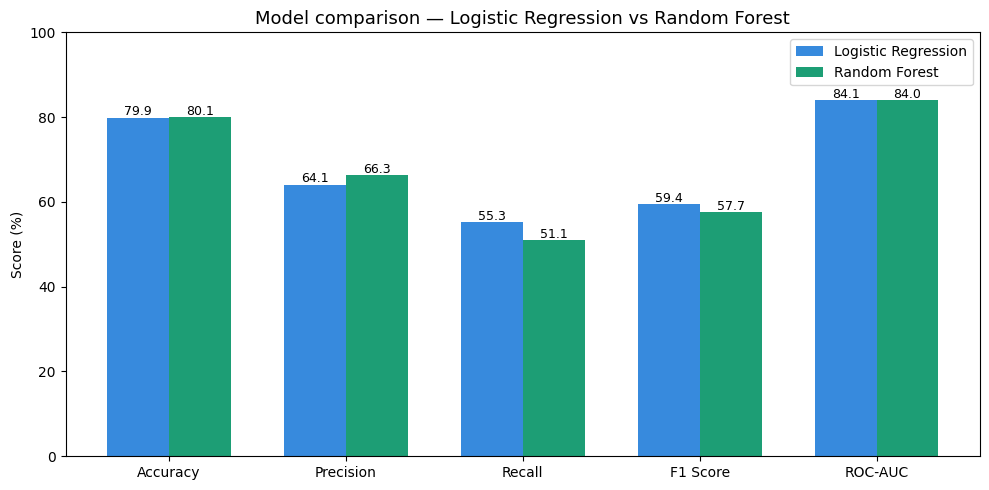

In [17]:
metrics = {
    'Metric':    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Logistic Regression': [
        accuracy_score(y_test, lr_preds),
        precision_score(y_test, lr_preds),
        recall_score(y_test, lr_preds),
        f1_score(y_test, lr_preds),
        roc_auc_score(y_test, lr_preds_prob)
    ],
    'Random Forest': [
        accuracy_score(y_test, rf_preds),
        precision_score(y_test, rf_preds),
        recall_score(y_test, rf_preds),
        f1_score(y_test, rf_preds),
        roc_auc_score(y_test, rf_preds_prob)
    ]
}

results_df = pd.DataFrame(metrics)
results_df['Logistic Regression'] = results_df['Logistic Regression'].mul(100).round(1)
results_df['Random Forest']       = results_df['Random Forest'].mul(100).round(1)
print(results_df.to_string(index=False))

# Bar chart comparison
x     = np.arange(len(metrics['Metric']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, results_df['Logistic Regression'], width, label='Logistic Regression', color='#378ADD', edgecolor='none')
bars2 = ax.bar(x + width/2, results_df['Random Forest'],       width, label='Random Forest',       color='#1D9E75', edgecolor='none')

ax.set_ylabel('Score (%)')
ax.set_title('Model comparison — Logistic Regression vs Random Forest', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics['Metric'])
ax.set_ylim(0, 100)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

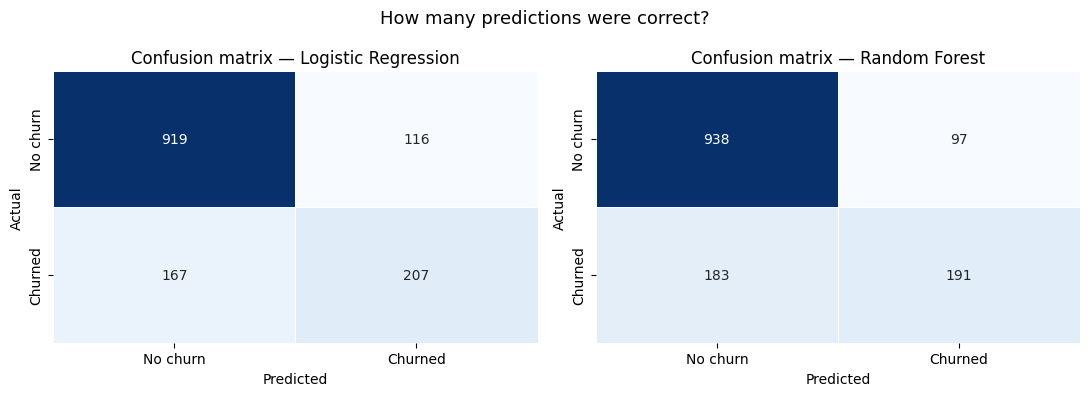

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, preds, title in zip(axes,
                             [lr_preds, rf_preds],
                             ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No churn', 'Churned'],
                yticklabels=['No churn', 'Churned'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'Confusion matrix — {title}', fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('How many predictions were correct?', fontsize=13, fontweight='500')
plt.tight_layout()
plt.savefig('chart_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

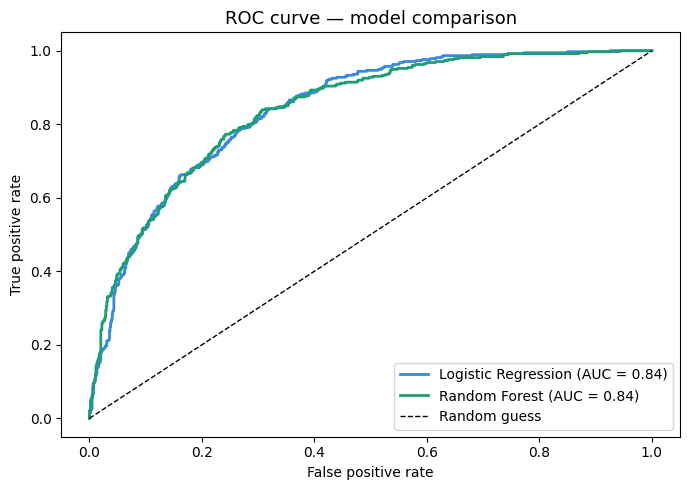

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

for preds_prob, label, color in [
    (lr_preds_prob, 'Logistic Regression', '#378ADD'),
    (rf_preds_prob, 'Random Forest',       '#1D9E75')
]:
    fpr, tpr, _ = roc_curve(y_test, preds_prob)
    auc          = roc_auc_score(y_test, preds_prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc:.2f})', color=color, linewidth=2)

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random guess')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve — model comparison', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('chart_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

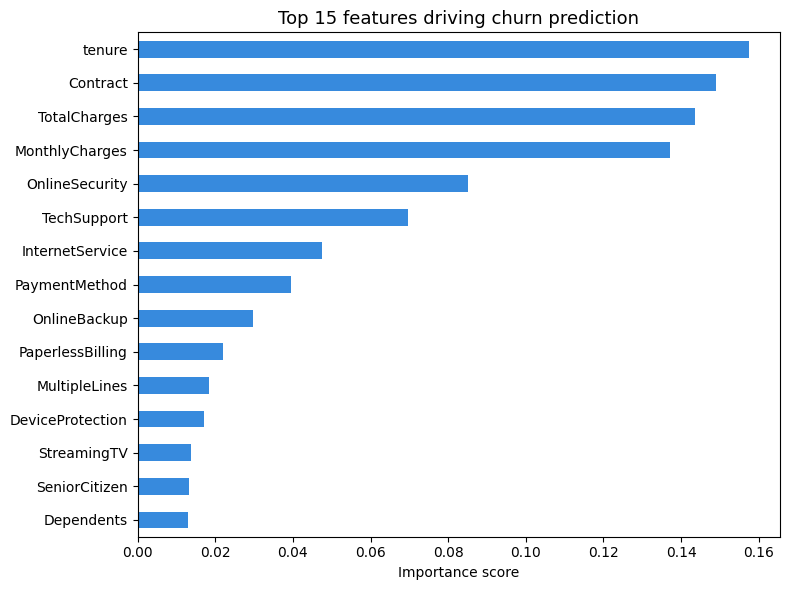


Top 5 most important features:
  tenure: 0.1576
  Contract: 0.1489
  TotalCharges: 0.1436
  MonthlyCharges: 0.1371
  OnlineSecurity: 0.0852


In [20]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='#378ADD', edgecolor='none')
ax.set_title('Top 15 features driving churn prediction', fontsize=13)
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('chart_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
for feat, score in importances.tail(5).sort_values(ascending=False).items():
    print(f"  {feat}: {score:.4f}")

In [21]:
# Add churn probability score to full dataset
df_encoded['churn_probability'] = rf_model.predict_proba(X)[:, 1]

df_encoded['risk_level'] = pd.cut(
    df_encoded['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low risk', 'Medium risk', 'High risk']
)

# At-risk customers
at_risk = df_encoded[df_encoded['churn_probability'] >= 0.6].copy()
at_risk = at_risk.sort_values('churn_probability', ascending=False)

print(f"Total customers scored: {len(df_encoded):,}")
print(f"\nRisk breakdown:")
print(df_encoded['risk_level'].value_counts())
print(f"\nHigh-risk customers (score ≥ 0.6): {len(at_risk):,}")

# Save for Power BI
df_encoded.to_csv('scored_customers.csv', index=False)
at_risk.to_csv('at_risk_customers.csv', index=False)
print("\nFiles saved: scored_customers.csv and at_risk_customers.csv")

Total customers scored: 7,043

Risk breakdown:
risk_level
Low risk       4365
Medium risk    1737
High risk       941
Name: count, dtype: int64

High-risk customers (score ≥ 0.6): 941

Files saved: scored_customers.csv and at_risk_customers.csv


Running SHAP analysis — takes ~30 seconds...


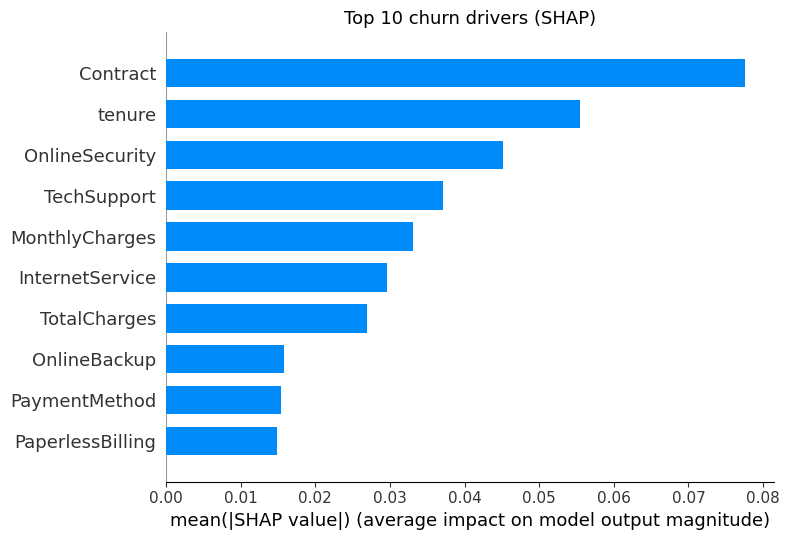

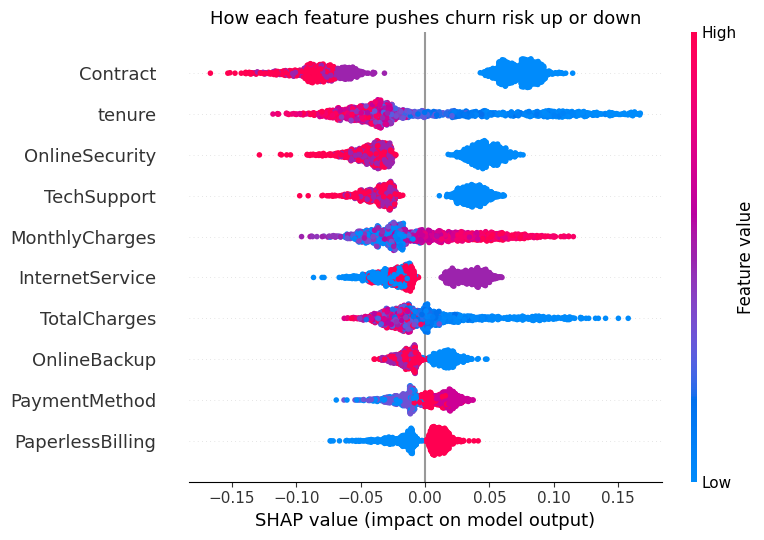

In [22]:
print("Running SHAP analysis — takes ~30 seconds...")

explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — top drivers of churn
plt.figure()
shap.summary_plot(shap_values[:,:,1], X_test,
                  plot_type='bar',
                  max_display=10,
                  show=False)
plt.title('Top 10 churn drivers (SHAP)', fontsize=13)
plt.tight_layout()
plt.savefig('chart_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Dot plot — direction of each feature's impact
plt.figure()
shap.summary_plot(shap_values[:,:,1], X_test,
                  max_display=10,
                  show=False)
plt.title('How each feature pushes churn risk up or down', fontsize=13)
plt.tight_layout()
plt.savefig('chart_shap_dot.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
print("=" * 55)
print("MODEL RESULTS SUMMARY")
print("=" * 55)
print(f"\nBest model: Random Forest")
print(f"ROC-AUC:    {roc_auc_score(y_test, rf_preds_prob)*100:.1f}%")
print(f"Recall:     {recall_score(y_test, rf_preds)*100:.1f}%")
print(f"  (catches {recall_score(y_test, rf_preds)*100:.0f}% of actual churners)")

print(f"\nCustomers flagged as high risk: {len(at_risk):,}")
print(f"  → These go into the churn playbook immediately")

print("\nTop 3 churn drivers from SHAP:")
top_features = importances.sort_values(ascending=False).head(3)
for i, (feat, score) in enumerate(top_features.items(), 1):
    print(f"  {i}. {feat} (importance: {score:.4f})")

print("\nFiles ready for Power BI:")
print("  scored_customers.csv")
print("  at_risk_customers.csv")

MODEL RESULTS SUMMARY

Best model: Random Forest
ROC-AUC:    84.0%
Recall:     51.1%
  (catches 51% of actual churners)

Customers flagged as high risk: 941
  → These go into the churn playbook immediately

Top 3 churn drivers from SHAP:
  1. tenure (importance: 0.1576)
  2. Contract (importance: 0.1489)
  3. TotalCharges (importance: 0.1436)

Files ready for Power BI:
  scored_customers.csv
  at_risk_customers.csv
